# MARL Notebook

### Using Jax for speedy reinforcement learning

Motivation: After developing our environment and training schedule, we ran into time and compute constraints
- Could not run more than ~40 envs on our computer, which for many timesteps took hours

Solution: Use Jax (via MuJoCo Playground environments) to speed things up
- Run in Google collab to get around Jax GPU OS constraints (Jax GPU is meant to run on Linux)

### Background

Jax compiles Python code into optimized machine code (usually via XLA)
- Traces Python functions, builds computation graph, generates machine code for device (GPU in this case)
- Jax can then reuse compiled code, which (combined with GPU speed), makes computations very fast
  - Caveats: Have to make some adjustments (e.g. no inner for loops as they cannot be vectorized by Jax)

Since Jax/JIT traces operations and builds a computation graph, we want to keep things relatively simple to avoid long computations
- Created a new Crazyflie XMl without all the collision geoms to speed things up
  - Previously, the physics integrator had to consider all collisions even if we never actually collided with anything
  - We weren't using these geoms anyway, as we end training episodes if drone(s) get to close to the ground or one another ("crash" but no collision)

### Resources

[MuJoCo Playground](https://github.com/google-deepmind/mujoco_playground) with example [Cartpole Balance RL Notebook](https://colab.research.google.com/github/google-deepmind/mujoco_playground/blob/main/learning/notebooks/dm_control_suite.ipynb)


In [2]:
#@title Install pre-requisites
!pip install mujoco
!pip install mujoco_mjx
!pip install brax
!pip install playground

# Rendering video
!command -v ffmpeg >/dev/null || (apt update && apt install -y ffmpeg)
!pip install -q mediapy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.0/42.0 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 95.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 243.5/243.5 kB 25.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 77.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 736.5/736.5 kB 60.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 344.1/344.1 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 172.4/172.4 kB 19.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.7/76.7 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.2/87.2 kB 505.7 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.4/7.4 MB 43.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 32.8 MB/s eta 0:00:00


In [3]:
# @title Check if MuJoCo installation was successful

import distutils.util
import os
import subprocess

if subprocess.run('nvidia-smi').returncode:
  raise RuntimeError(
      'Cannot communicate with GPU. '
      'Make sure you are using a GPU Colab runtime. '
      'Go to the Runtime menu and select Choose runtime type.'
  )

# Add an ICD config so that glvnd can pick up the Nvidia EGL driver.
# This is usually installed as part of an Nvidia driver package, but the Colab
# kernel doesn't install its driver via APT, and as a result the ICD is missing.
# (https://github.com/NVIDIA/libglvnd/blob/master/src/EGL/icd_enumeration.md)
NVIDIA_ICD_CONFIG_PATH = '/usr/share/glvnd/egl_vendor.d/10_nvidia.json'
if not os.path.exists(NVIDIA_ICD_CONFIG_PATH):
  with open(NVIDIA_ICD_CONFIG_PATH, 'w') as f:
    f.write("""{
    "file_format_version" : "1.0.0",
    "ICD" : {
        "library_path" : "libEGL_nvidia.so.0"
    }
}
""")

# Configure MuJoCo to use the EGL rendering backend (requires GPU)
print('Setting environment variable to use GPU rendering:')
%env MUJOCO_GL=egl

try:
  print('Checking that the installation succeeded:')
  import mujoco

  mujoco.MjModel.from_xml_string('<mujoco/>')
except Exception as e:
  raise e from RuntimeError(
      'Something went wrong during installation. Check the shell output above '
      'for more information.\n'
      'If using a hosted Colab runtime, make sure you enable GPU acceleration '
      'by going to the Runtime menu and selecting "Choose runtime type".'
  )

print('Installation successful.')

# Tell XLA to use Triton GEMM, this improves steps/sec by ~30% on some GPUs
xla_flags = os.environ.get('XLA_FLAGS', '')
xla_flags += ' --xla_gpu_triton_gemm_any=True'
os.environ['XLA_FLAGS'] = xla_flags

Setting environment variable to use GPU rendering:
env: MUJOCO_GL=egl
Checking that the installation succeeded:
Installation successful.


In [25]:
# @title Crazyflie Config

from mujoco_playground._src import mjx_env
import mujoco
from mujoco import mjx
import jax
import jax.numpy as jnp
import numpy as np
from ml_collections import config_dict

import mediapy as media
from typing import Any

# Importing Scene from Google Drive (mounted folder)
# Using simplified models without collisions to reduce Jax graph computations
# Don't use collisions anyway, env terminates if drone is near ground
SCENE_PATH_1_DRONE = "/content/drive/MyDrive/assets_mjx/bitcraze_crazyflie_2/scene.xml"
SCENE_PATH_2_DRONES = "/content/drive/MyDrive/assets_mjx/bitcraze_crazyflie_2/scene_multi.xml"

# Adjust XML scene and number of training steps based on number of drones
NUM_DRONES = 2
SCENE_PATH = SCENE_PATH_2_DRONES if NUM_DRONES > 1 else SCENE_PATH_1_DRONE
PPO_TIMESTEPS = 150_000_000 if NUM_DRONES > 1 else 75_000_000

# Basic info
BASE_HOVER_THRUST = 0.26487
TARGET_POS = jnp.array([0.0, 0.0, 0.5])
QPOS_PER_DRONE = 7  # pos + quat
QVEL_PER_DRONE = 6  # linear vel + angular vel

# Random starting state sampled from distribution
TRAINING_POS_RANGE = 2.0
DRONE_SPACING_ALONG_AXIS = 0.4
TRAINING_QUAT_RANGE = np.pi / 8
TRAINING_VEL_RANGE = 0.2
TRAINING_ANG_VEL_RANGE = 0.1

# Out of bounds if N distance further from target compared to starting distance
OUT_OF_BOUNDS_RANGE = 2.0

# Reward and observation constants
TERMINATION_WEIGHT = 1.0
SURVIVAL_WEIGHT = TERMINATION_WEIGHT / 1000
DRONE_PROXIMITY_WEIGHT = 0.01
TARGET_PROXIMITY_WEIGHT = 0.01

DRONE_PROXIMITY_THRESHOLD = 0.25
DRONE_COLLISION_THRESHOLD = 0.1

N_PREV_ACTIONS = 4


# Helper function to convert drone quaternion to rotation matrix
def quat_to_rotation_matrix(q):
    """q is [w, x, y, z]"""
    w, x, y, z = q
    return jnp.array([
        [1 - 2*(y**2 + z**2), 2*(x*y - z*w),     2*(x*z + y*w)],
        [2*(x*y + z*w),       1 - 2*(x**2 + z**2), 2*(y*z - x*w)],
        [2*(x*z - y*w),       2*(y*z + x*w),     1 - 2*(x**2 + y**2)]
    ])

In [26]:
# @title Crazyflie Env

class CrazyflieEnv(mjx_env.MjxEnv):
    """Simple MJX environment using the Crazyflie drone model."""

    def __init__(self):
        # Define environment configuration (control and sim time steps)
        cfg = config_dict.ConfigDict()
        cfg.ctrl_dt = 0.02    # control step (50Hz)
        cfg.sim_dt = 0.002    # simulation step (500Hz)
        super().__init__(cfg)

        # Load MuJoCo model and convert to MJX
        self._mj_model = mujoco.MjModel.from_xml_path(SCENE_PATH)
        self._mjx_model = mjx.put_model(self._mj_model)

        # Define control/action size as number of actuators
        self._action_size = self._mj_model.nu

        # If using multiple drones, arrange them in a line (along X axis for now)
        self.dir_x, self.dir_y = 1.0, 0.0
        self.drone_offsets = jnp.linspace(-(NUM_DRONES - 1) / 2, (NUM_DRONES - 1) / 2, NUM_DRONES) * DRONE_SPACING_ALONG_AXIS


    # Expected env properties for Brax PPO training
    @property
    def xml_path(self) -> str:
        return SCENE_PATH

    @property
    def action_size(self) -> int:
        return self.mjx_model.nu

    @property
    def mj_model(self) -> mujoco.MjModel:
        return self._mj_model

    @property
    def mjx_model(self) -> mjx.Model:
        return self._mjx_model


    def reset(self, rng: jax.Array) -> mjx_env.State:
        """Vectorized reset for Crazyflie drones."""

        # Random keys
        rng, rng_pos, rng_quat, rng_vel, rng_ang = jax.random.split(rng, 5)

        # Random starting positions for drone(s) based on the target pos
        std_pos = TRAINING_POS_RANGE / 2.0
        pos_noise = jax.random.normal(rng_pos, (NUM_DRONES, 3)) * std_pos
        start_pos = TARGET_POS + pos_noise
        start_pos = start_pos.at[:, 2].set(jnp.clip(start_pos[:, 2], 0.1, jnp.inf))

        # Drone offset along drones starting axis
        offset_xy = jnp.stack([
            self.drone_offsets * self.dir_x,
            self.drone_offsets * self.dir_y,
            jnp.zeros_like(self.drone_offsets)
        ], axis=1)
        start_pos += offset_xy

        # Random quaternions
        std_angle = TRAINING_QUAT_RANGE / 2.0
        axes = jax.random.normal(rng_quat, (NUM_DRONES, 3))
        axes = axes / jnp.linalg.norm(axes, axis=1, keepdims=True)
        angles = jax.random.normal(rng_quat, (NUM_DRONES,)) * std_angle
        w = jnp.cos(angles)
        quats = jnp.concatenate([w[:, None], axes * jnp.sin(angles)[:, None]], axis=1)

        # Linear and angular velocities
        lin_vel = (TRAINING_VEL_RANGE / 2.0) * jax.random.normal(rng_vel, (NUM_DRONES, 3))
        ang_vel = (TRAINING_ANG_VEL_RANGE / 2.0) * jax.random.normal(rng_ang, (NUM_DRONES, 3))

        # Assemble qpos/qvel in batch
        qpos = jnp.zeros((NUM_DRONES, QPOS_PER_DRONE), dtype=jnp.float32)
        qpos = qpos.at[:, 0:3].set(start_pos)
        qpos = qpos.at[:, 3:7].set(quats)
        qpos = qpos.reshape(-1)  # flatten for mjx_env

        qvel = jnp.zeros((NUM_DRONES, QVEL_PER_DRONE), dtype=jnp.float32)
        qvel = qvel.at[:, 0:3].set(lin_vel)
        qvel = qvel.at[:, 3:6].set(ang_vel)
        qvel = qvel.reshape(-1)  # flatten for mjx_env

        # Initialize state
        action_history = jnp.zeros((N_PREV_ACTIONS * self._action_size,))
        initial_distance = jnp.linalg.norm(start_pos - TARGET_POS, axis=1)

        data = mjx_env.init(self._mjx_model, qpos=qpos, qvel=qvel)

        # Metrics
        metrics = {
            "reward/distance_improvement": jnp.zeros(()),
            "reward/proximity_bonus": jnp.zeros(()),
            "reward/survival_bonus": jnp.zeros(()),
            "reward/termination": jnp.zeros(()),
            "reward/drone_proximity_penalty": jnp.zeros(()),
            "reward": jnp.zeros(())
        }

        # State info
        info = {
            "rng": rng,
            "initial_distance": initial_distance,
            "prev_pos": start_pos,
            "action_history": jnp.zeros((N_PREV_ACTIONS * self._action_size,)),
        }

        reward = jnp.zeros(())
        done = jnp.zeros(())

        obs = self._get_obs(data, info)

        return mjx_env.State(data=data, obs=obs, reward=reward, done=done, metrics=metrics, info=info)


    def step(self, state: mjx_env.State, action: jax.Array) -> mjx_env.State:
        """Vectorized Crazyflie step for multiple drones with MARL rewards."""

        # Clip action (by default done via XML actuators but we are also recording action history)
        action_clipped = action.at[0::4].set(jnp.clip(action[0::4], 0.0, 0.35))   # thrusts
        action_clipped = action_clipped.at[1::4].set(jnp.clip(action[1::4], -1.0, 1.0))  # rolls
        action_clipped = action_clipped.at[2::4].set(jnp.clip(action[2::4], -1.0, 1.0))  # pitches
        action_clipped = action_clipped.at[3::4].set(jnp.clip(action[3::4], -1.0, 1.0))  # yaws

        data = mjx_env.step(self._mjx_model, state.data, action_clipped, n_substeps=self.n_substeps)
        obs = self._get_obs(data, state.info)

        qpos = data.qpos.reshape(NUM_DRONES, QPOS_PER_DRONE)

        # Retrieve stateful info for drone(s)
        prev_pos = state.info["prev_pos"]
        init_dist = state.info["initial_distance"]

        # Dynamic step rewards: Distance to target improvement and target proximity
        pos = qpos[:, :3]
        distance_to_target = jnp.linalg.norm(TARGET_POS - pos, axis=1)
        distance_to_target_old = jnp.linalg.norm(TARGET_POS - prev_pos, axis=1)
        distance_improvement = distance_to_target_old - distance_to_target

        proximity_bonus = TARGET_PROXIMITY_WEIGHT * (1 - jnp.tanh(distance_to_target))

        # Compute pairwise distances between drones
        diffs = pos[:, None, :] - pos[None, :, :]  # (N, N, 3)
        dists = jnp.linalg.norm(diffs + jnp.eye(NUM_DRONES)[..., None] * 1e9, axis=-1)  # (N, N)

        # Proximity penalty for being closer than threshold to another drone
        proximity_penalty_matrix = jnp.where(
            dists < DRONE_PROXIMITY_THRESHOLD,
            DRONE_PROXIMITY_WEIGHT * (1.0 - dists / DRONE_PROXIMITY_THRESHOLD),
            0.0,
        )
        # Zero out self-distances
        proximity_penalty_matrix = proximity_penalty_matrix * (1.0 - jnp.eye(NUM_DRONES))
        drone_proximity_penalty = jnp.sum(proximity_penalty_matrix, axis=1)

        # Collision check
        collision_matrix = (dists < DRONE_COLLISION_THRESHOLD).astype(jnp.float32)
        collision_any = jnp.clip(jnp.sum(collision_matrix * (1 - jnp.eye(NUM_DRONES)), axis=1), 0, 1)

        # Termination conditions: Crash, stray from target, drone collision
        done = (
            (pos[:, 2] < 0.05)
            | (distance_to_target > init_dist + OUT_OF_BOUNDS_RANGE)
            | (collision_any > 0)
        )

        # Reward per drone, 1D jax arrays of shape (NUM_DRONES,)
        reward_per_drone = (
            SURVIVAL_WEIGHT
            + proximity_bonus
            + distance_improvement
            - drone_proximity_penalty
            - done.astype(jnp.float32) * TERMINATION_WEIGHT
        )

        # Aggregate (mean) reward for the environment
        reward = jnp.mean(reward_per_drone)
        done_all = jnp.any(done).astype(jnp.float32)

        # Aggregate per-drone metrics to scalars per environment (match Brax format)
        new_metrics = {
            "reward/distance_improvement": jnp.mean(distance_improvement),
            "reward/proximity_bonus": jnp.mean(proximity_bonus),
            "reward/survival_bonus": SURVIVAL_WEIGHT * NUM_DRONES,
            "reward/termination": - done_all * TERMINATION_WEIGHT,
            "reward/drone_proximity_penalty": - jnp.mean(drone_proximity_penalty),
            "reward": reward,
        }

        # Update info (prev pos and action history)
        new_action_history = jnp.concatenate([
            state.info["action_history"][action_clipped.size:],
             action_clipped
        ])
        new_info = dict(state.info)
        new_info["prev_pos"] = pos
        new_info["action_history"] = new_action_history

        return mjx_env.State(
            data=data,
            obs=obs,
            reward=reward,
            done=done_all,
            metrics=new_metrics,
            info=new_info,
        )


    # Base obs: pos + vel + angular velocity
    # Engineered obs: Rot matrix + relative pos (body) + vel (body) + Action history
    def _get_obs(self, data, info):
        qpos = data.qpos.reshape(NUM_DRONES, QPOS_PER_DRONE)
        qvel = data.qvel.reshape(NUM_DRONES, QVEL_PER_DRONE)

        # Convert drone(s) quat to rotation matrix
        quat = qpos[:, 3:7]
        rot_mats = jax.vmap(quat_to_rotation_matrix)(quat) # (N, 3, 3)

        # Get relative position to target in drone body coordinates
        pos = qpos[:, :3]
        pos_error = TARGET_POS - pos # (N, 3)
        rel_pos_body = jnp.einsum('nij,nj->ni', rot_mats.transpose((0, 2, 1)), pos_error)

        # Get linear velocity in drone body coordinates
        vel = qvel[:, :3]
        linear_vel_body = jnp.einsum('nij,nj->ni', rot_mats.transpose((0, 2, 1)), vel)

        ang_vel = qvel[:, 3:6]

        obs_core = jnp.concatenate([pos, vel, ang_vel, rot_mats.reshape(NUM_DRONES, -1), rel_pos_body, linear_vel_body], axis=1)
        return jnp.concatenate([obs_core.reshape(-1), info["action_history"]])

In [27]:
# @title Crazyflie Rollout Example

def run_rollout():
    env = CrazyflieEnv()
    jit_env_reset = jax.jit(env.reset)
    jit_env_step = jax.jit(env.step)

    key = jax.random.PRNGKey(42)
    state = jit_env_reset(key)
    rollout = [state]

    episode_length = 1000

    print("Crazyflie Test Rollout")
    print("Starting pos:", np.asarray(state.info["prev_pos"]))
    print(f"Initial obs shape: {state.obs.shape}")
    print("=" * 60)

    for i in range(episode_length):
        # Thrust up action
        action = jnp.tile(jnp.array([BASE_HOVER_THRUST + 0.05, 0.0, 0.0, 0.0]), (NUM_DRONES,))

        # Step the environment
        state = jit_env_step(state, action)
        rollout.append(state)

        # Convert JAX arrays to NumPy for readable printing
        metrics_np = jax.tree_util.tree_map(
            lambda x: np.asarray(x).item() if np.size(x) == 1 else np.asarray(x),
            state.metrics
        )
        ctrl_np = np.asarray(action)
        prev_pos_np = np.asarray(state.info.get("prev_pos", np.zeros(3)))

        # Parse Obs
        obs_np = np.asarray(state.obs)
        pos = obs_np[0:3]
        lin_vel = obs_np[6:9]
        ang_vel = obs_np[9:12]

        # Logs
        print(f"\n\nStep {i:04d}, Action {ctrl_np}, Reward {float(state.reward):+.4f}")
        print(f"  \nReward breakdown")
        print(f"    Dist Improvement: {metrics_np.get('reward/distance_improvement', np.nan):+.4f}")
        print(f"    Target Proximity Bonus: {metrics_np.get('reward/proximity_bonus', np.nan):+.4f}")
        print(f"    Survival Bonus: {metrics_np.get('reward/survival_bonus', np.nan):+.4f}")
        print(f"    Drone Proximity Penalty: {metrics_np.get('reward/drone_proximity_penalty', np.nan):+.4f}")
        print(f"    Termination: {metrics_np.get('reward/termination', np.nan):+.4f}")

        print(f"  \nPartial observation breakdown for drone 1")
        print(f"    Pos: {pos}")
        print(f"    Linear vel:   {lin_vel}")
        print(f"    Angular vel:         {ang_vel}")

        # Terminate if done
        if bool(state.done):
            print(f"\nEnvironment terminated at step {i} (done=True)")
            break

    # Utility to render target as geom in scene
    print("\nRendering trajectory...")
    target_geom_id = mujoco.mj_name2id(env.mj_model, mujoco.mjtObj.mjOBJ_GEOM, b"target")

    def move_target_geom(scene: mujoco.MjvScene, target_pos: np.ndarray):
        scene.geoms[target_geom_id].pos[:] = target_pos

    modify_target_fn = lambda scene: move_target_geom(scene, TARGET_POS)

    # Collect frames, use track camera from xml scene and update geom pos to target pos
    frames = env.render(
        rollout,
        camera="track",
        modify_scene_fns=[modify_target_fn] * len(rollout),
    )
    media.show_video(frames, fps=1.0 / env.dt)

    # Summary
    rewards = [float(s.reward) for s in rollout]
    print(f"\nTotal steps: {len(rewards)}, Final reward: {rewards[-1]:.4f}")

run_rollout()

Crazyflie Test Rollout
Starting pos: [[ 0.40576404  0.7990441   0.1       ]
 [-0.43525755 -1.2226585   0.1       ]]
Initial obs shape: (80,)


Step 0000, Action [0.31487 0.      0.      0.      0.31487 0.      0.      0.     ], Reward +0.0034
  
Reward breakdown
    Dist Improvement: +0.0006
    Target Proximity Bonus: +0.0019
    Survival Bonus: +0.0020
    Drone Proximity Penalty: -0.0000
    Termination: -0.0000
  
Partial observation breakdown for drone 1
    Pos: [0.40536225 0.796171   0.09709126]
    Linear vel:   [0.03274024 0.00869081 0.08009031]
    Angular vel:         [0.98730624 0.14283828 0.06945255]


Step 0001, Action [0.31487 0.      0.      0.      0.31487 0.      0.      0.     ], Reward +0.0038
  
Reward breakdown
    Dist Improvement: +0.0010
    Target Proximity Bonus: +0.0019
    Survival Bonus: +0.0020
    Drone Proximity Penalty: -0.0000
    Termination: -0.0000
  
Partial observation breakdown for drone 1
    Pos: [0.40528464 0.7930199  0.09490463]
    Linear v

100%|██████████| 97/97 [00:00<00:00, 326.68it/s]


This browser does not support the video tag.



Total steps: 97, Final reward: -0.5553


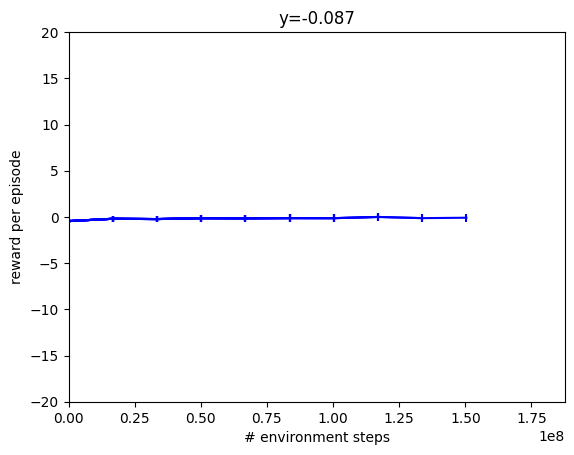

time to jit: 0:00:56.396381
time to train: 0:54:27.961416


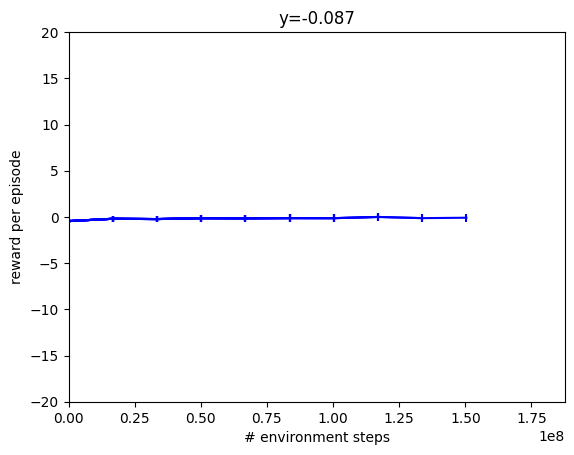

In [28]:
# @title Crazyflie Training

from datetime import datetime
import functools
from IPython.display import clear_output, display
import matplotlib.pyplot as plt
import mediapy as media
import jax
import jax.numpy as jnp
import numpy as np
from ml_collections import config_dict

from mujoco_playground import wrapper
from brax.training.agents.ppo import networks as ppo_networks
from brax.training.agents.ppo import train as ppo
from mujoco_playground.config import dm_control_suite_params


# Progress plots
x_data, y_data, y_dataerr = [], [], []
times = [datetime.now()]
def progress(num_steps, metrics):
    clear_output(wait=True)
    times.append(datetime.now())
    x_data.append(num_steps)
    y_data.append(metrics["eval/episode_reward"])
    y_dataerr.append(metrics["eval/episode_reward_std"])

    plt.xlim([0, ppo_params["num_timesteps"] * 1.25])
    plt.ylim([-20, 20])
    plt.xlabel("# environment steps")
    plt.ylabel("reward per episode")
    plt.title(f"y={y_data[-1]:.3f}")
    plt.errorbar(x_data, y_data, yerr=y_dataerr, color="blue")
    display(plt.gcf())

# Anneal LR
def linear_annealing_lr(init_lr, final_lr, num_timesteps):
    def schedule(step):
        progress = step / num_timesteps
        return init_lr + progress * (final_lr - init_lr)
    return schedule

# PPO training parameters
ppo_params = config_dict.create(
    num_timesteps=PPO_TIMESTEPS,
    num_evals=10,
    episode_length=1500,
    normalize_observations=True,
    action_repeat=1,
    unroll_length=30,
    num_minibatches=32,
    num_updates_per_batch=16,
    discounting=0.995,
    learning_rate=linear_annealing_lr(3e-3, 3e-5,  PPO_TIMESTEPS),
    entropy_cost=1e-3,
    num_envs=2048,
    batch_size=1024,
)

ppo_training_params = dict(ppo_params)
network_factory = ppo_networks.make_ppo_networks
if "network_factory" in ppo_params:
    del ppo_training_params["network_factory"]
    network_factory = functools.partial(
        ppo_networks.make_ppo_networks,
        **ppo_params.network_factory
    )

train_fn = functools.partial(
    ppo.train,
    **dict(ppo_training_params),
    network_factory=network_factory,
    progress_fn=progress
)

# Create environment
env = CrazyflieEnv()

# Train PPO agent - make_inference_fn is our policy function, params are network parameters, metrics are training stats
# Wrap env for training to match Brax format (e.g. add device and env dimensions to obs)
make_inference_fn, params, metrics = train_fn(
    environment=env,
    wrap_env_fn=wrapper.wrap_for_brax_training,
)
print(f"time to jit: {times[1] - times[0]}")
print(f"time to train: {times[-1] - times[1]}")

In [29]:
#@title Crazyflie Evaluation
env = CrazyflieEnv()

jit_reset = jax.jit(env.reset)
jit_step = jax.jit(env.step)
jit_inference_fn = jax.jit(make_inference_fn(params, deterministic=True))

rng = jax.random.PRNGKey(42)
rollout = []
n_episodes = 1

for _ in range(n_episodes):
  state = jit_reset(rng)
  rollout.append(state)
  for i in range(ppo_params["episode_length"]):
    if bool(state.done):
        break
    act_rng, rng = jax.random.split(rng)
    ctrl, _ = jit_inference_fn(state.obs, act_rng)
    state = jit_step(state, ctrl)
    rollout.append(state)

    # Logs
    metrics_np = jax.tree_util.tree_map(lambda x: np.asarray(x).item() if np.size(x) == 1 else np.asarray(x), state.metrics)
    ctrl_np = np.asarray(ctrl)
    prev_pos_np = np.asarray(state.info.get("prev_pos", np.zeros(3)))

    # Print progress
    print(f"\nStep {i:04d}: Action {[f'{x:.4f}' for x in ctrl_np]}")
    print(
        f"Rewards: | "
        f"Dist Impr: {metrics_np.get('reward/distance_improvement', np.nan):.4f} | "
        f"Target Prox: {metrics_np.get('reward/proximity_bonus', np.nan):.4f} | "
        f"Survival: {metrics_np.get('reward/survival_bonus', np.nan):.4f} | "
        f"Drone Prox: {metrics_np.get('reward/drone_proximity_penalty', np.nan):+.4f} | "
        f"Termination: {metrics_np.get('reward/termination', np.nan):+.4f}"
    )
    print(f"Prev Pos: {prev_pos_np}")


# Utility to render target as geom in scene based on env target pos
target_geom_id = mujoco.mj_name2id(env.mj_model, mujoco.mjtObj.mjOBJ_GEOM, b"target")
def move_target_geom(scene: mujoco.MjvScene, target_pos: np.ndarray):
    scene.geoms[target_geom_id].pos[:] = target_pos

modify_target_fn = lambda scene: move_target_geom(scene, TARGET_POS)
frames = env.render(rollout, camera="track", modify_scene_fns=[lambda scene: move_target_geom(scene, TARGET_POS)]*len(rollout))

rewards = [s.reward for s in rollout]
media.show_video(frames, fps=1.0 / env.dt)


Step 0000: Action ['0.7923', '-0.6968', '0.1258', '0.2599', '0.7816', '-0.4247', '-0.6656', '0.4132']
Rewards: | Dist +/-: 0.0007 | Target Prox: 0.0019 | Survival: 0.0020 | Drone Prox: -0.0000 | Termination: -0.0000
Prev Pos: [[ 0.40538028  0.7961555   0.09735033]
 [-0.4346894  -1.2232963   0.10103275]]

Step 0001: Action ['0.7915', '-0.6933', '0.1162', '0.2543', '0.7811', '-0.4259', '-0.6620', '0.4088']
Rewards: | Dist +/-: 0.0013 | Target Prox: 0.0019 | Survival: 0.0020 | Drone Prox: -0.0000 | Termination: -0.0000
Prev Pos: [[ 0.40535673  0.7929574   0.09594067]
 [-0.4342228  -1.223675    0.10331872]]

Step 0002: Action ['0.7933', '-0.4324', '0.5139', '0.2182', '0.7868', '-0.1686', '-0.5691', '0.2510']
Rewards: | Dist +/-: 0.0018 | Target Prox: 0.0019 | Survival: 0.0020 | Drone Prox: -0.0000 | Termination: -0.0000
Prev Pos: [[ 0.40569344  0.7894457   0.09577023]
 [-0.433854   -1.2238002   0.10685733]]

Step 0003: Action ['0.7917', '-0.5114', '0.5643', '0.2095', '0.7628', '-0.1848', 

100%|██████████| 92/92 [00:00<00:00, 185.79it/s]


This browser does not support the video tag.
